In [254]:
# signal X on graph = node features 
# Multi resolution analsyis decomposes L^2(G) into V_0 ... where V_0 is coarsest and as j increases, V_j gets finer
# I have some filter/func g_c(lambda) which is a piecewise const function over freq axis
# with one learnable heigher per bin (theta_j,k)
# Spectral Convolution is: H = U . G_c . U^T . X . W where W is learnable weight, M = U . G_c . U^T
# Each encoder layer is H_u^i = signa(M . H_c^i-1 . W^i-1) where H_u^0 = X
# GAT -> spectral encoder 


In [255]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import os
from tqdm import tqdm
import traceback
import matplotlib.pyplot as plt

In [256]:

# works out correlation matrix for returns in window size K ending at t - so up to time t
def correlation_matrix(returns, t, K, eps=0.0, active=None):
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')
    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        window = window[active]

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]
    active_cols = window.columns.tolist()

    #scaler = MinMaxScaler(feature_range=(0, 1))
    #windowed_returns = scaler.fit_transform(windowed_returns)
    #windowed_returns = (windowed_returns - windowed_returns.min()) / (windowed_returns.max() - windowed_returns.min() + 1e-8)
    corr_matrix = window.corr().values
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    return corr_matrix, active_cols

In [257]:
# layer gives me attention weights for edges - gives A_+ and A_-
class GATLayer(torch.nn.Module):
    
    src_nodes_dim = 0  # position of source nodes in edge index
    trg_nodes_dim = 1  # position of target nodes in edge index

    nodes_dim = 0      # node dimension (the position of "N" in tensor)
    head_dim = 1      # attention head dim

    def __init__(self, num_in_features, num_out_features, num_of_heads, concat=True, activation=nn.ELU(),
                 dropout_prob=0.1, add_skip_connection=True, bias=True, log_attention_weights=True):

        super().__init__()

        self.num_of_heads = num_of_heads # number of attention heads - mine has a positive and negative head so 2
        self.num_out_features = num_out_features
        self.concat = concat  # whether we should concatenate or average the attention heads
        self.add_skip_connection = add_skip_connection

        # treat this one matrix as num_of_heads independent W matrices
        self.linear_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)

        # After we concatenate target node (node i) and source node (node j) we apply the additive scoring function
        # which gives us un-normalized score "e". we split the "a" vector - but the semantics remain the same.
        # Basically instead of doing [x, y] (concatenation, x/y are node feature vectors) and dot product with "a"
        # we instead do a dot product between x and "a_left" and y and "a_right" and we sum them up
        # these params will be updated during training (below)
        self.scoring_fn_target = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))
        self.scoring_fn_source = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))

        # Bias is definitely not crucial to GAT - feel free to experiment (I pinged the main author, Petar, on this one)
        if bias and concat:
            self.bias = nn.Parameter(torch.Tensor(num_of_heads * num_out_features))
        elif bias and not concat:
            self.bias = nn.Parameter(torch.Tensor(num_out_features))
        else:
            self.register_parameter('bias', None) # no bias

        if add_skip_connection:
            self.skip_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)
        else:
            self.register_parameter('skip_proj', None)


        self.leakyReLU = nn.LeakyReLU(0.2)  # using 0.2 as in the paper, no need to expose every setting
        self.activation = activation
        # Probably not the nicest design but I use the same module in 3 locations, before/after features projection
        # and for attention coefficients. Functionality-wise it's the same as using independent modules.
        self.dropout = nn.Dropout(p=dropout_prob)

        self.log_attention_weights = log_attention_weights  # whether we should log the attention weights
        self.attention_weights = None  # for later visualization purposes, I cache the weights here

        self.init_params()
        
    def forward(self, data):
        # Step 1: Linear Projection + regularization

        in_nodes_features, edge_index, corr = data  # unpack data - corr contains N x N correlation matrix at time t 
        num_of_nodes = in_nodes_features.shape[self.nodes_dim]
        assert edge_index.shape[0] == 2, f'Expected edge index with shape=(2,E) got {edge_index.shape}'

        # shape = (N, FIN) where N - number of nodes in the graph, FIN - number of input features per node
        # apply the dropout to all of the input node features (as mentioned in the paper)
        # can try without this part as an experiment
        in_nodes_features = self.dropout(in_nodes_features)

        # shape = (N, FIN) * (FIN, NH*FOUT) -> (N, NH, FOUT) where NH - number of heads, FOUT - num of output features
        # We project the input node features into NH independent output features (one for each attention head)
        nodes_features_proj = self.linear_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        # can try without this
        nodes_features_proj = self.dropout(nodes_features_proj)  # in the official GAT imp they did dropout here as well

        # Step 2:edge attention calculation

        # Apply the scoring function (* represents element-wise (a.k.a. Hadamard) product)
        # shape = (N, NH, FOUT) * (1, NH, FOUT) -> (N, NH, 1) -> (N, NH) because sum squeezes the last dimension
        # Optimization note: torch.sum() is as performant as .sum() in my experiments
        scores_source = (nodes_features_proj * self.scoring_fn_source).sum(dim=-1)
        scores_target = (nodes_features_proj * self.scoring_fn_target).sum(dim=-1)

        # We simply copy (lift) the scores for source/target nodes based on the edge index. Instead of preparing all
        # the possible combinations of scores we just prepare those that will actually be used and those are defined
        # by the edge index.
        # scores shape = (E, NH), nodes_features_proj_lifted shape = (E, NH, FOUT), E - number of edges in the graph
        scores_source_lifted, scores_target_lifted, nodes_features_proj_lifted = self.lift(scores_source, scores_target, nodes_features_proj, edge_index)
        scores_per_edge = self.leakyReLU(scores_source_lifted + scores_target_lifted)
        #scores_per_edge = self.mask_function(scores_per_edge, edge_index)
        
        src = edge_index[self.src_nodes_dim]
        trg = edge_index[self.trg_nodes_dim]

        # corr is N x N, extract per-edge correlations (E,)
        corr_e = corr[src, trg] 
        # masks (E, 1) so they broadcast across heads
        mask_pos = (corr_e >= 0).float().unsqueeze(-1)
        mask_neg = (corr_e < 0).float().unsqueeze(-1)

        # two masked attentions, each normalized over the same target-neighborhood
        att_pos = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_pos)
        att_neg = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_neg)

        # treat them as two separate sign heads
        attentions_per_edge = torch.cat([att_pos, att_neg], dim=1)  # (E, 2*NH, 1)
        attentions_per_edge = self.dropout(attentions_per_edge)
        self.attention_weights = attentions_per_edge  # for later visualization
        return (attentions_per_edge, edge_index, corr)
        
    def neighborhood_aware_softmax(self, scores_per_edge, trg_index, num_of_nodes, mask):
        # Calculate the numerator. Make logits <= 0 so that e^logit <= 1 (this will improve the numerical stability)
        scores_per_edge = scores_per_edge - scores_per_edge.max()
        exp_scores_per_edge = scores_per_edge.exp()  # softmax
        exp_scores_per_edge = exp_scores_per_edge * mask

        # Calculate the denominator. shape = (E, NH)
        neigborhood_aware_denominator = self.sum_edge_scores_neighborhood_aware(exp_scores_per_edge, trg_index, num_of_nodes)
        # 1e-16 is theoretically not needed but is only there for numerical stability (avoid div by 0) - due to the
        # possibility of the computer rounding a very small number all the way to 0.
        attentions_per_edge = exp_scores_per_edge / (neigborhood_aware_denominator + 1e-16)
        # shape = (E, NH) -> (E, NH, 1) so that we can do element-wise multiplication with projected node features
        return attentions_per_edge.unsqueeze(-1)

    def sum_edge_scores_neighborhood_aware(self, exp_scores_per_edge, trg_index, num_of_nodes):
        # The shape must be the same as in exp_scores_per_edge (required by scatter_add_) i.e. from E -> (E, NH)
        trg_index_broadcasted = self.explicit_broadcast(trg_index, exp_scores_per_edge)
        # shape = (N, NH), where N is the number of nodes and NH the number of attention heads
        size = list(exp_scores_per_edge.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes
        neighborhood_sums = torch.zeros(size, dtype=exp_scores_per_edge.dtype, device=exp_scores_per_edge.device)
        # position i will contain a sum of exp scores of all the nodes that point to the node i (as dictated by the
        # target index)
        neighborhood_sums.scatter_add_(self.nodes_dim, trg_index_broadcasted, exp_scores_per_edge)
        # Expand again so that we can use it as a softmax denominator. e.g. node i's sum will be copied to
        # all the locations where the source nodes pointed to i (as dictated by the target index)
        # shape = (N, NH) -> (E, NH)
        return neighborhood_sums.index_select(self.nodes_dim, trg_index)

    def aggregate_neighbors(self, nodes_features_proj_lifted_weighted, edge_index, in_nodes_features, num_of_nodes):
        size = list(nodes_features_proj_lifted_weighted.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes  # shape = (N, NH, FOUT)
        out_nodes_features = torch.zeros(size, dtype=in_nodes_features.dtype, device=in_nodes_features.device)

        # shape = (E) -> (E, NH, FOUT)
        trg_index_broadcasted = self.explicit_broadcast(edge_index[self.trg_nodes_dim], nodes_features_proj_lifted_weighted)
        # aggregation step - we accumulate projected, weighted node features for all the attention heads
        # shape = (E, NH, FOUT) -> (N, NH, FOUT)
        out_nodes_features.scatter_add_(self.nodes_dim, trg_index_broadcasted, nodes_features_proj_lifted_weighted)

        return out_nodes_features

    def lift(self, scores_source, scores_target, nodes_features_matrix_proj, edge_index):
        #Lift duplicates certain vectors depending on the edge index.
        #One of the tensor dims goes from N -> E (that's where the "lift" comes from)

        src_nodes_index = edge_index[self.src_nodes_dim]
        trg_nodes_index = edge_index[self.trg_nodes_dim]

        # Using index_select is faster than "normal" indexing (scores_source[src_nodes_index]) in PyTorch!
        scores_source = scores_source.index_select(self.nodes_dim, src_nodes_index)
        scores_target = scores_target.index_select(self.nodes_dim, trg_nodes_index)
        nodes_features_matrix_proj_lifted = nodes_features_matrix_proj.index_select(self.nodes_dim, src_nodes_index)

        return scores_source, scores_target, nodes_features_matrix_proj_lifted

    def explicit_broadcast(self, this, other):
        # Append singleton dimensions until this.dim() == other.dim()
        for _ in range(this.dim(), other.dim()):
            this = this.unsqueeze(-1)

        # Explicitly expand so that shapes are the same
        return this.expand_as(other)

    def init_params(self): # TODO: try changing initialization
        """
        The reason we're using Glorot (aka Xavier uniform) initialization is because it's a default TF initialization:
            https://stackoverflow.com/questions/37350131/what-is-the-default-variable-initializer-in-tensorflow

        The original repo was developed in TensorFlow (TF) and they used the default initialization.
        Feel free to experiment - there may be better initializations depending on your problem.

        """
        nn.init.xavier_uniform_(self.linear_proj.weight)
        nn.init.xavier_uniform_(self.scoring_fn_target)
        nn.init.xavier_uniform_(self.scoring_fn_source)

        if self.bias is not None:
            torch.nn.init.zeros_(self.bias)

    def skip_concat_bias(self, attention_coefficients, in_nodes_features, out_nodes_features):
        if self.log_attention_weights:  # potentially log for later visualization in playground.py
            self.attention_weights = attention_coefficients

        if self.add_skip_connection:  # add skip or residual connection
            if out_nodes_features.shape[-1] == in_nodes_features.shape[-1]:  # if FIN == FOUT
                # unsqueeze does this: (N, FIN) -> (N, 1, FIN), out features are (N, NH, FOUT) so 1 gets broadcast to NH
                # thus we're basically copying input vectors NH times and adding to processed vectors
                out_nodes_features += in_nodes_features.unsqueeze(1)
            else:
                # FIN != FOUT so we need to project input feature vectors into dimension that can be added to output
                # feature vectors. skip_proj adds lots of additional capacity which may cause overfitting.
                out_nodes_features += self.skip_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        if self.concat:
            # shape = (N, NH, FOUT) -> (N, NH*FOUT)
            out_nodes_features = out_nodes_features.view(-1, self.num_of_heads * self.num_out_features)
        else:
            # shape = (N, NH, FOUT) -> (N, FOUT)
            out_nodes_features = out_nodes_features.mean(dim=self.head_dim)

        if self.bias is not None:
            out_nodes_features += self.bias

        return out_nodes_features if self.activation is None else self.activation(out_nodes_features)

In [258]:
from torch.optim import Adam

class GAT(torch.nn.Module): # gives me attention weights matrices for edges - gives A_+ and A_-

    def __init__(self, num_of_layers, num_heads_per_layer, num_features_per_layer, add_skip_connection=True, bias=True,
                 dropout=0.1, log_attention_weights=True):
        super().__init__()
        assert num_of_layers == len(num_heads_per_layer) == len(num_features_per_layer) - 1, f'Enter valid arch params.'

        num_heads_per_layer = [1] + num_heads_per_layer  # trick - so that I can nicely create GAT layers below

        gat_layers = []  # collect GAT layers
        for i in range(num_of_layers):
            layer = GATLayer(
                num_in_features=num_features_per_layer[i] * num_heads_per_layer[i],  # consequence of concatenation
                num_out_features=num_features_per_layer[i+1],
                num_of_heads=num_heads_per_layer[i+1],
                concat=True if i < num_of_layers - 1 else False,  # last GAT layer does mean avg, the others do concat
                activation=nn.ELU() if i < num_of_layers - 1 else None,  # last layer just outputs raw scores
                dropout_prob=dropout,
                add_skip_connection=add_skip_connection,
                bias=bias,
                log_attention_weights=log_attention_weights
            )
            gat_layers.append(layer)

        self.gat_net = nn.Sequential(
            *gat_layers,
        )

    # data is just a (in_nodes_features, edge_index) tuple:

    def forward(self, data):
        return self.gat_net(data)[0]

In [260]:
## testing the GAT layer and attention to adjacency conversion
# data = (infeatures, edge_index, corr_matrix)
test_gat = GAT(num_of_layers=1, num_heads_per_layer=[2], num_features_per_layer=[16, 8], add_skip_connection=True, bias=True,
                 dropout=0.1, log_attention_weights=True)
in_feats = torch.randn(5, 16)  # (N, FIN)
edge_index = torch.tensor([[0,0,1,1,2],[1,2,0,3,4]])
corr = torch.tensor([[1., 0.5, -0.2, 0., 0.],
                     [0.5, 1., 0.3, 0., 0.],
                     [-0.2, 0.3, 1., 0., 0.],
                     [0., 0., 0., 1., 0.4],
                     [0., 0., 0., 0.4, 1.]])

node_out = test_gat((in_feats, edge_index, corr))
edge_att = test_gat.gat_net[-1].attention_weights  # (E, 2*NH, 1) — only works after the fix

A_pos, A_neg = attention_to_adjacency(edge_att, edge_index, 5)


In [271]:
N=5
X_t = torch.randn(N, 11)  # (N, feature_dim)
H_t = torch.randn(N, 10)  # (N, embedding_dim)
h_prev_pos = torch.randn(N, 32)  # (N, hidden_dim)
h_prev_neg = torch.randn(N, 32)  # (N, hidden_dim
h_t_pos, h_t_neg, loss, signals, _, _ = model(
                    X_t, H_t, edge_index, corr, 
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, 
                    A_t_pos=A_pos, A_t_neg=A_neg
                )

_LinAlgError: linalg.eigh: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated eigenvalues (error code: 4).

In [ ]:
def attention_to_adjacency(attention_weights, edge_index, num_nodes):

        E = edge_index.shape[1] # (2, E -> 0 is src, 1 is trg)
        #NH = attention_weights.shape[1] // 2 # (E, 2*NH, 1)
        att = attention_weights[:,:,0].mean(dim=1) # (E, 2*NH) -> (E,) average over heads
        # Average over attention heads
        #att_pos = attention_weights[:, :NH, 0].mean(dim=1)  # (E,)
        #att_neg = attention_weights[:, NH:, 0].mean(dim=1)  # (E,)
        att_pos = torch.relu(att)
        att_neg = torch.relu(-att)
        # Create sparse adjacency matrices
        src = edge_index[0]
        trg = edge_index[1]
        
        A_pos = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        A_neg = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        
        A_pos[src, trg] = att_pos
        A_neg[src, trg] = att_neg
        
        # Make symmetric -> graph is undirected
        A_pos = (A_pos + A_pos.T) / 2
        A_neg = (A_neg + A_neg.T) / 2
        
        return A_pos, A_neg

In [ ]:

def compute_initial_node_embeddings(returns, t, K, eps=0.0, active=None):
    node_embeddings = {}
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')
    
    # Check if window is empty
    if windowed_returns.empty:
        return {}, []

    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        # Intersect active with available columns
        valid_active = [c for c in active if c in window.columns]
        if not valid_active:
            return {}, []
        window = window[valid_active]
        
    if window.shape[0] < 2 or window.shape[1] == 0: # Need at least some data
        return {}, []

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]

    active_cols = window.columns.tolist()
    if not active_cols:
        return {}, []

    U, S, Vt = np.linalg.svd(window.values, full_matrices=False)
    V = Vt.T
    H = V @ np.diag(S)
    H = H[:, :10]

    # Handle case where SVD returns fewer than 10 components
    if H.shape[1] < 10:
        padding = np.zeros((H.shape[0], 10 - H.shape[1]))
        H = np.hstack([H, padding])
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    H = scaler.fit_transform(H)

    for i, stock in enumerate(active_cols):
        node_embeddings[stock] = H[i, :] # contains only one embedding per stock at time t, embedding shape (10,)
        
    # here - store the array directly in the list to match our structure
    for stock in node_embeddings:
        node_embeddings[stock] = np.array(node_embeddings[stock])
        
    return node_embeddings, active_cols

In [ ]:

class DiffusionConvLayer(nn.Module):
    
    #At each diffusion step s, compute:
    #Z_+ = sum_{s=0}^{S-1} θ_s,1 × (A_+_norm)^s × X
    #Z_- = sum_{s=0}^{S-1} θ_s,2 × (A_-_norm)^s × X
    #Output: [Z_+ || Z_-] concatenated
    
    def __init__(self, in_features, out_channels, num_diffusion_steps=1, bias=True):
    #in_features: Input feature dimension = d
    #out_channels: Number of output channels per network (Q)
    #num_diffusion_steps: Number of diffusion steps (S)
        super().__init__()
        
        self.in_features = in_features
        self.out_channels = out_channels
        self.num_diffusion_steps = num_diffusion_steps
        
        # Learnable diffusion filters: one set for positive, one for negative
        # Shape: (S, d, Q) for each
        self.theta_pos = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        self.theta_neg = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        
        if bias:
            self.bias_pos = nn.Parameter(torch.Tensor(out_channels))
            self.bias_neg = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)
            
        self.reset_parameters()
        
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.theta_pos)
        nn.init.xavier_uniform_(self.theta_neg)
        if self.bias_pos is not None:
            nn.init.zeros_(self.bias_pos)
        if self.bias_neg is not None:
            nn.init.zeros_(self.bias_neg)
    
    def forward(self, X_pos, X_neg, A_pos, A_neg):
        N = X_pos.shape[0] # X is N x d
        
        # Normalize adjacency matrices for random walk
        # D^(-1) × A
        D_pos = A_pos.sum(dim=1, keepdim=True) + 1e-8  # (N, 1)
        D_neg = A_neg.sum(dim=1, keepdim=True) + 1e-8
        A_t_pos_norm = A_pos / D_pos  # (N, N)
        A_neg_norm = A_neg / D_neg
        
        # Initialize outputs
        Z_pos = torch.zeros(N, self.out_channels, device=X_pos.device) # 0's
        Z_neg = torch.zeros(N, self.out_channels, device=X_neg.device)

        # Positive diffusion
        A_power = torch.eye(N, device=X_pos.device)  # A^0 = Identity matrix
        for s in range(self.num_diffusion_steps):
            # θ_s × (A^s × X) for each output channel where s is the diffusion step
            # A_power: (N, N), X: (N, d), theta_pos[s]: (d, Q)
            diffused = A_power @ X_pos  # (N, d)
            Z_pos += diffused @ self.theta_pos[s]  # (N, d) @ (d, Q) = (N, Q) 
            A_power = A_power @ A_t_pos_norm  # Update A^s
        
        # Negative diffusion
        A_power = torch.eye(N, device=X_neg.device)
        for s in range(self.num_diffusion_steps):
            diffused = A_power @ X_neg
            Z_neg += diffused @ self.theta_neg[s]
            A_power = A_power @ A_neg_norm
        
        # Concatenate positive and negative outputs
        #Z = torch.cat([Z_pos, Z_neg], dim=1)  # (N, 2Q)

        if self.bias_pos is not None:
            Z_pos = Z_pos + self.bias_pos

        if self.bias_neg is not None:
            Z_neg = Z_neg + self.bias_neg

        return Z_pos, Z_neg # each is (N, Q)


In [262]:
# Spectral Convolution is: H = U . G_c . U^T . X . W where W is learnable weight, M = U . G_c . U^T
# Each encoder layer is H_u^i = signa(M . H_c^i-1 . W^i-1) where H_u^0 = X

class SpectralEncoder(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, K=16):
        super().__init__()

        self.num_layers = num_layers
        self.K = K  # number of Haar bins (frequency resolution)
        
        # Learnable Haar filter coefficients - one set per layer
        # These are the theta_k values that define g_c(lambda)
        self.filter_coeffs_pos = nn.ParameterList([
            nn.Parameter(torch.ones(K)) for _ in range(num_layers)
        ])

        self.filter_coeffs_neg = nn.ParameterList([
            nn.Parameter(torch.ones(K)) for _ in range(num_layers)
        ])
        
        # Learnable weight matrices W^(i) - one per layer
        dims = [input_dim] + [hidden_dim] * (num_layers - 1) + [output_dim]
        self.weights = nn.ParameterList()
        for i in range(num_layers):
            w = nn.Parameter(torch.randn(dims[i], dims[i+1]))
            nn.init.xavier_uniform_(w)  # Xavier initialization
            self.weights.append(w)
        
        self.activation = nn.ReLU()

    def forward(self, X, A_pos, A_neg):
        num_nodes = X.shape[0]

        L_pos = self.compute_laplacian(A_pos, num_nodes)
        L_neg = self.compute_laplacian(A_neg, num_nodes)

        #eigendecomposition
        eigenvals_pos, eigenvects_pos = self.decomposition(L_pos)
        eigenvals_neg, eigenvects_neg = self.decomposition(L_neg)
        
        #mlti-layer spectral convolution so initalise H_0 to be X = node features
        H_pos = X
        H_neg = X
        
        for i in range(self.num_layers):
            # Build learned filters for this layer
            g_c_pos = self.build_filter(eigenvals_pos, self.filter_coeffs_pos[i])
            g_c_neg = self.build_filter(eigenvals_neg, self.filter_coeffs_neg[i])
            
            # Build diffusion operators M = U . G_c . U^T
            M_pos = self.build_diffusion_operator(eigenvects_pos, g_c_pos)
            M_neg = self.build_diffusion_operator(eigenvects_neg, g_c_neg)
            
            # H^(i) = sigma(M . H^(i-1) . W^(i-1))
            H_pos = self.activation(M_pos @ H_pos @ self.weights[i])
            H_neg = self.activation(M_neg @ H_neg @ self.weights[i])
        
        return H_pos, H_neg


    def decomposition(self, L):
        L = L + 1e-4 * torch.eye(L.shape[0], device=L.device)  # add small value to diagonal for numerical stability
        eigenvals, eigenvects = torch.linalg.eigh(L)
        return eigenvals, eigenvects
    

    def compute_laplacian(self, A, num_nodes):

        deg = (A > 0).float().sum(dim=1)
        deg_inv_sqrt = torch.zeros_like(deg)
        mask = deg > 0
        deg_inv_sqrt[mask] = 1.0 / torch.sqrt(deg[mask])
        D_inv_sqrt = torch.diag(deg_inv_sqrt)
        
        A_norm = D_inv_sqrt @ A @ D_inv_sqrt
        L = torch.eye(num_nodes, device=A.device) - A_norm

        return L

    def build_filter(self, eigenvalues, filter_coeffs):
 
        #eigenvalues: (num_nodes,) values in [0, 2]
        # filter_coeffs: (K,) learnable theta values
        
        #returns (num_nodes,) filter values, one per eigenvalue
        K = filter_coeffs.shape[0]
        # bin_width = 2.0 / K  # divide [0, 2] into K equal bins
        
        # # Which bin does each eigenvalue fall into?
        # # Clamp to handle eigenvalues exactly at 2.0
        # bin_indices = torch.clamp((eigenvalues / bin_width).long(), max=K-1) # .long() to assign eigenvalues to bins, which breaks gradient flow - integer indexing is not differentiable
        
        # # Look up the learned coefficient for each eigenvalue's bin
        # g_c = filter_coeffs[bin_indices]  # (num_nodes,)

        # TODO: Try use this instead asw
        bin_centers = torch.linspace(1.0/K, 2.0 - 1.0/K, K, device=eigenvalues.device)
    
        # Soft assignment: each eigenvalue gets a weighted combination of nearby bins
        # (num_nodes, 1) - (K,) -> (num_nodes, K)
        distances = (eigenvalues.unsqueeze(1) - bin_centers.unsqueeze(0)) ** 2
        temperature = (2.0 / K) ** 2  # scale by bin width
        soft_assignments = torch.softmax(-distances / temperature, dim=1)
        
        # Weighted sum of filter coefficients
        g_c = soft_assignments @ filter_coeffs  # (num_nodes,)

        return g_c

    def build_diffusion_operator(self, eigenvectors, g_c):
        #find M = U . G_c . U^T
        #eigenvectors: U matrix
        #g_c: (num_nodes,) diagonal entries of G_c from build filter func
        #returns: (num_nodes, num_nodes) the diffusion operator M

        G_c = torch.diag(g_c)  # (num_nodes, num_nodes)
        M = eigenvectors @ G_c @ eigenvectors.T
        return M

In [263]:
class GraphConvGRUCell(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_diffusion_steps=1):

        super().__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        # Diffusion layers for reset gate
        self.conv_r = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
        # Diffusion layers for update gate
        self.conv_u = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
        # Diffusion layers for candidate activation
        self.conv_c = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
    def forward(self, x_t_pos, x_t_neg, h_prev_pos, h_prev_neg, A_pos, A_neg):
        # Concatenate input and previous hidden state
        combined_pos = torch.cat([x_t_pos, h_prev_pos], dim=1)  # (N, input_dim + hidden_dim)
        combined_neg = torch.cat([x_t_neg, h_prev_neg], dim=1)  # (N, input_dim + hidden_dim)

        # Reset gate: r_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        r_pos, r_neg = self.conv_r(combined_pos, combined_neg, A_pos, A_neg)  # (N, hidden_dim) each
        r_t_pos, r_t_neg = torch.sigmoid(r_pos), torch.sigmoid(r_neg)  # (N, hidden_dim) each

        # Update gate: u_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        u_pos, u_neg = self.conv_u(combined_pos, combined_neg, A_pos, A_neg)
        u_t_pos, u_t_neg = torch.sigmoid(u_pos), torch.sigmoid(u_neg)  # (N, hidden_dim) each

        # Candidate: c_t = tanh(DiffConv([x_t, r_t * h_{t-1}]))
        #positive
        h_tilde_pos = r_t_pos * h_prev_pos  # Element-wise product
        h_tilde_neg = r_t_neg * h_prev_neg  # Element-wise product
        combined_c_pos = torch.cat([x_t_pos, h_tilde_pos], dim=1)
        combined_c_neg = torch.cat([x_t_neg, h_tilde_neg], dim=1)
        c_pos, c_neg = self.conv_c(combined_c_pos, combined_c_neg, A_pos, A_neg)
        c_t_pos, c_t_neg = torch.tanh(c_pos), torch.tanh(c_neg)  # (N, hidden_dim) each

        # Update hidden state: h_t = u_t * h_{t-1} + (1 - u_t) * c_t
        h_t_pos = u_t_pos * h_prev_pos + (1 - u_t_pos) * c_t_pos
        h_t_neg = u_t_neg * h_prev_neg + (1 - u_t_neg) * c_t_neg
        
        return h_t_pos, h_t_neg
    

In [264]:
class StructuralDecoder(nn.Module): # estimate degree using MLP on h_u^Z = (Nxoutput_dim)
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.est_degree = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, 1)
        )

    def forward(self, h_u, true_deg):
        d_pred = self.est_degree(h_u) # shape (N, 1)
        true_deg = true_deg.unsqueeze(-1)
        per_node_loss = (d_pred - true_deg) ** 2  # (N, 1)
        loss = per_node_loss.mean()  # scalar loss
        struct_err = torch.norm(true_deg - d_pred, dim=1) # shape (N,) structural error per node
        return loss, per_node_loss.squeeze(-1), d_pred, struct_err.unsqueeze(-1) # shape (N, 1) structural error per node

In [265]:
class NeighbourDecoder(nn.Module): # reconstruct distr of node's neighbourhood's features
    def __init__(self, hidden_dim, input_dim):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.input_dim = input_dim

        self.pred_mean = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim), 
            nn.ReLU(), 
            nn.Linear(self.hidden_dim, self.input_dim)
        )

        self.pred_log_var = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim), 
            nn.ReLU(), 
            nn.Linear(self.hidden_dim, self.input_dim)
        )

        #self.loss = nn.KLDivLoss(reduction="batchmean")

    def compute_actual_stats(self, X, A):
        N, d = X.shape
        eps = 1e-6

        # Normalise attention weights so each row sums to 1
        weight_sum = A.sum(dim=1, keepdim=True).clamp(min=eps)  # (N, 1)
        A_norm = A / weight_sum  # (N, N)

        # Number of actual neighbours (for covariance denominator: 1/(d_u - 1))
        num_neighbours = (A > 0).float().sum(dim=1)  # (N,)

        #mu_u = (1/d_u) * sum_{v in N_u} h_v^(0)
        true_mean = A_norm @ X  # (N, d)

        # Sigma_u = (1/(d_u-1)) * sum_{v in N_u} (h_v - mu_u)(h_v - mu_u)^T + eps*I
        # We need (N, d, d) covariance matrices
        true_cov = torch.zeros(N, d, d, device=X.device)

        for i in range(N):
            # Get neighbours and their weights
            neighbour_mask = A[i] > 0  # which nodes are neighbours
            if neighbour_mask.sum() < 2:
                # Not enough neighbours for covariance, use identity
                true_cov[i] = torch.eye(d, device=X.device) * eps
                continue

            neighbour_features = X[neighbour_mask]  # (num_neighbours_i, d)
            diff = neighbour_features - true_mean[i].unsqueeze(0)  # (num_neighbours_i, d)

            # Weighted covariance
            weights = A[i][neighbour_mask]  # (num_neighbours_i,)
            weights = weights / weights.sum()  # normalise

            # (d, num_neighbours_i) @ diag(weights) @ (num_neighbours_i, d)
            weighted_diff = diff * weights.unsqueeze(1)  # (num_neighbours_i, d)
            cov = diff.T @ weighted_diff  # (d, d)

            # Scale by d_u/(d_u - 1) for unbiased estimate + regularise
            n_i = neighbour_mask.sum().float()
            cov = cov * (n_i / (n_i - 1)) + eps * torch.eye(d, device=X.device)

            true_cov[i] = cov

        return true_mean, true_cov

    def kl_divergence(self, pred_mean, pred_log_var, true_mean, true_cov):
        N, p = pred_mean.shape
        pred_log_var = pred_log_var.clamp(-10, 10)
        # Predicted covariance is diagonal: Sigma_hat = diag(exp(log_var))
        pred_var = torch.exp(pred_log_var)  # (N, d)

        # Term 1: log(|Sigma_hat| / |Sigma|)
        # log|Sigma_hat| = sum of log(pred_var) since it's diagonal
        log_det_pred = pred_log_var.sum(dim=1)  # (N,)
        # log|Sigma| = log det of full covariance
        #log_det_true = torch.linalg.slogdet(true_cov)[1]  # (N,)
        sign, log_det_true = torch.linalg.slogdet(true_cov)
        log_det_true = log_det_true.clamp(-50, 50)
        term1 = log_det_pred - log_det_true  # (N,)

        # Term 2: -p
        term2 = -p

        # tr(Sigma_hat^{-1} @ Sigma)
        # Sigma_hat^{-1} is diagonal with entries 1/pred_var
        # tr(diag(1/pred_var) @ Sigma) = sum_j Sigma_jj / pred_var_j
        pred_var_inv = 1.0 / pred_var.clamp(min=1e-6)  # (N, d)
        # Extract diagonal of true_cov: (N, d)
        true_cov_diag = torch.diagonal(true_cov, dim1=1, dim2=2)  # (N, d)
        term3 = (pred_var_inv * true_cov_diag).sum(dim=1)  # (N,)

        # (mu - mu_hat)^T Sigma_hat^{-1} (mu - mu_hat)
        # Since Sigma_hat^{-1} is diagonal, this is sum of (diff^2 / pred_var)
        mean_diff = true_mean - pred_mean  # (N, d)
        term4 = (mean_diff ** 2 * pred_var_inv).sum(dim=1)  # (N,)

        # Equation 14
        kl = 0.5 * (term1 + term2 + term3 + term4)  # (N,)

        N, p = pred_mean.shape
    
        kl = kl.clamp(min=0, max=1000)

        return kl


    def forward(self, h_u, X, A):

        pred_mean = self.pred_mean(h_u)  # (N, d)
        pred_log_var = self.pred_log_var(h_u)  # (N, d)

        # True distribution (Equations 12, 13)
        true_mean, true_cov = self.compute_actual_stats(X, A) # shapes (N, d) and (N, d, d)

        # KL divergence (Equation 14)
        per_node_loss = self.kl_divergence(pred_mean, pred_log_var, true_mean, true_cov)
        avg_loss = per_node_loss.mean()

        #neighbour_err_mean = torch.norm(pred_mean - true_mean, dim=1) # shape (N,) neighbour error per node
        #neighbour_err_cov = torch.norm(pred_cov - true_cov, dim=(1,2)) # shape (N,) neighbour error per node

        return avg_loss, per_node_loss, pred_mean, pred_log_var # shape (N, 1) neighbour error per node

In [266]:
def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    active = window.columns[ok_obs & ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active

In [267]:
def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
                           beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

    rows = []
    t = pd.to_datetime(t)
    if not stocks:
        return torch.empty((0, 2), dtype=torch.float32)
    for stock in stocks:
        # Get factors for stock at time t (or default values if missing)
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
        pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
        implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
        short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
        beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
        op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
        roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
        rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
        turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

        # Get volatility at time t (or nearest available)
        if t in volatility.index and stock in volatility.columns:
            vol = volatility.loc[t, stock]
        else:
            # Get closest date
            available_dates = volatility.index[volatility.index <= t]
            if len(available_dates) > 0:
                closest_date = available_dates[-1]
                vol = volatility.loc[closest_date, stock]
            else:
                vol = 0.0  # Default if no data available
        rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
        # features is (N, 11)
        features = np.array(rows, dtype=np.float32)
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


        if len(features) >0:
            num_cols = features.shape[1]
            for i in range(num_cols):  # Normalize each feature to [0, 1]
                if features[:, i].max() > features[:, i].min():
                    features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

        non_zero_count = np.count_nonzero(features)
        total_elements = features.size
        zero_fraction = 1.0 - (non_zero_count / total_elements)
        
        if zero_fraction > 0.9: # If more than 90% of data is zero
            print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
            print("Sample Row (first stock):", features[0])
            # Check raw dataframe lookup for one stock to debug
            test_stock = stocks[0]
            print(f"Debug check for {test_stock} at {t}:")
            if test_stock in pe_ratios.columns:
                # Check if exact date exists
                date_exists = t in pe_ratios.index
                print(f"  - Date {t} in PE_ratios index? {date_exists}")
                if not date_exists:
                    # Show nearest dates
                    print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")
                
    return torch.tensor(features, dtype=torch.float32)


def create_edge_index(corr_matrix, k_neighbors=15):
    """
    Creates an edge index where each node connects to its top-k most correlated peers.
    """
    N = corr_matrix.shape[0]
    if isinstance(corr_matrix, np.ndarray):
        corr = torch.tensor(corr_matrix, dtype=torch.float32)
    else:
        corr = corr_matrix.clone()

    #diagonal to -infinity so a node doesn't select itself
    mask_diag = torch.eye(N, dtype=torch.bool, device=corr.device)
    corr.masked_fill_(mask_diag, float('-inf'))
    
    # includes strong positive and strong negative correlations
    vals, indices = torch.topk(corr.abs(), k=min(k_neighbors, N-1), dim=1)
    
    # create Edge List
    
    src_list = torch.arange(N, device=corr.device).repeat_interleave(k_neighbors)
    trg_list = indices.flatten()
    
    edge_index = torch.stack([src_list, trg_list], dim=0)
    
    return edge_index

def create_adjacency_from_correlation(corr_matrix, threshold=0.0):
    C = np.array(corr_matrix, dtype=np.float32)
    A_pos = np.maximum(C, 0.0)     
    A_neg = np.maximum(-C, 0.0)
    A_pos[A_pos < threshold] = 0 # min correlation to include edge
    A_neg[A_neg < threshold] = 0
    np.fill_diagonal(A_pos, 0) # self-loops
    np.fill_diagonal(A_neg, 0) # self-loops
    return torch.tensor(A_pos, dtype=torch.float32), torch.tensor(A_neg, dtype=torch.float32) # (N, N) is A



In [268]:
#model = SpectralModel(
#     gat_config=gat_config,
#     hidden_dim=32,  # GRU hidden dimension
#     output_dim=16  # Spectral encoder output dimension
# )
class GRASPEDmodel(nn.Module):
    def __init__(self, gat_config, hidden_dim, output_dim, feature_dim=11, dropout=0.1):
        # feature_dim: dimension of X_t (raw node features from prepare_node_features)
        # gat_config['features'][0]: dimension of H_t (PCA embeddings, used only by GAT)
        super().__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.gat = GAT(
            num_of_layers=gat_config['num_layers'],
            num_heads_per_layer=gat_config['heads'],
            num_features_per_layer=gat_config['features'],
            dropout=dropout
        )

        self.spectral_encoder = SpectralEncoder(
            input_dim=feature_dim,  # X_t has feature_dim dims (NOT GAT output dim)
            hidden_dim=self.hidden_dim,
            output_dim=self.output_dim,
            num_layers=2
        )

        self.GRU = GraphConvGRUCell(
            input_dim=self.output_dim,
            hidden_dim=self.hidden_dim,
            num_diffusion_steps=1
        )

        self.structural_decoder = StructuralDecoder(hidden_dim=self.hidden_dim)
        self.neighbour_decoder = NeighbourDecoder(hidden_dim=self.hidden_dim, input_dim=feature_dim)  # reconstructs X_t

    
    def forward(self, X_t, H_t, edge_index, corr_matrix, h_prev_pos=None, h_prev_neg=None, A_t_pos=None, A_t_neg=None, true_deg=None):

        N = X_t.shape[0]
        if h_prev_pos is None:
            h_prev_pos = torch.zeros(N, self.hidden_dim, device=X_t.device)
        if h_prev_neg is None:
            h_prev_neg = torch.zeros(N, self.hidden_dim, device=X_t.device)
        # GAT forward pass: uses H_t (PCA embeddings, embedding_dim) to learn graph structure
        node_features = self.gat((H_t, edge_index, corr_matrix))  # (N, gat_output_dim) - not used directly, only for attention weights
        attention_weights = self.gat.gat_net[-1].attention_weights  # (E, 2*NH, 1)
        A_pos_est, A_neg_est = attention_to_adjacency(attention_weights, edge_index, N)  # (N, N)

        # Spectral Encoder forward pass: uses X_t (raw features, feature_dim)
        h_u_pos, h_u_neg = self.spectral_encoder(X_t, A_pos_est, A_neg_est)  # (N, output_dim)
        # GRU update
        h_t_pos, h_t_neg = self.GRU(h_u_pos, h_u_neg, h_prev_pos, h_prev_neg, A_pos_est, A_neg_est)
        # Structural Decoder loss
        true_deg = (A_pos_est > 0).float().sum(dim=1) + (A_neg_est > 0).float().sum(dim=1)

        struct_loss_pos, _, deg_pred_pos, struct_err_pos = self.structural_decoder(h_t_pos, true_deg)
        struct_loss_neg, _, deg_pred_neg, struct_err_neg = self.structural_decoder(h_t_neg, true_deg)

        # Neighbour Decoder loss: reconstructs X_t (feature_dim)
        neigh_loss_pos, neigh_err_pos, _, _ = self.neighbour_decoder(h_t_pos, X_t, A_pos_est)
        neigh_loss_neg, neigh_err_neg, _, _ = self.neighbour_decoder(h_t_neg, X_t, A_neg_est)

        total_loss = 0.5 * (struct_loss_pos + struct_loss_neg) + 0.5 * (neigh_loss_pos + neigh_loss_neg)
        print(f"Structural Loss: {struct_loss_pos.item():.4f} (pos), {struct_loss_neg.item():.4f} (neg) | Neighbour Loss: {neigh_loss_pos.item():.4f} (pos), {neigh_loss_neg.item():.4f} (neg)")
        combined_signal = 0.5 * (neigh_err_pos + neigh_err_neg) + 0.5 * (struct_err_pos + struct_err_neg)  # (N, 1)

        return h_t_pos, h_t_neg, total_loss, combined_signal, deg_pred_pos, deg_pred_neg

In [ ]:
def train_model(model, optimizer, returns, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest,
                 Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, 
                train_dates,stock2idx, K=21, save_path='checkpoints'):
    
    device = next(model.parameters()).device
    #stocks = list(returns.columns)          # global universe order
    #stock2idx = {s: i for i, s in enumerate(stocks)}
    N_full = len(stock2idx)
    #stocks = list(returns.columns)
    #N = len(stocks)
    
    # Create edge index once (or you can recreate per timestamp)
    feature_dfs_list = [
    volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, 
    Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover
    ]

    training_losses = []
    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state

    print(f"Training on {len(train_dates)} time steps...")
    
    for epoch in range(3):  # Multiple passes through training data
        epoch_losses = []
        #h_prev = None  # Reset hidden state each epoch
        
        for t in tqdm(train_dates, desc=f"Epoch {epoch+1}"):
            try:
                # Get active stocks at time t
                active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
                if not active: continue
                returns_t = returns[active]
                volatility_t = volatility[active]
                market_caps_t = Market_caps[active]
                PE_ratios_t = PE_ratios[active]
                Implied_vol_t = Implied_vol[active]
                Short_interest_t = Short_interest[active]
                Beta_t = Beta[active]
                Operating_margin_t = Operating_margin[active]
                Return_on_equity_t = Return_on_equity[active]
                RSI_momentum_t = RSI_momentum[active]
                Turnover_t = Turnover[active]
                stocks_t = active
                N_t = len(stocks_t)
                # 1. Compute PCA embeddings from returns
                node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K)
                
                # Extract embeddings for all stocks
                H_list = []
                for stock in stocks_t:
                    if stock in node_embeddings:
                        emb = node_embeddings[stock]
                        if len(emb.shape) > 1 and emb.shape[0] == 1:
                            H_list.append(emb[0])  # Take first embedding
                        else:
                            H_list.append(emb)
                        #H_list.append(node_embeddings[stock][0])  # Take first embedding
                    else:
                        # Default embedding
                        H_list.append(np.zeros(10))  # Assuming L=10
                
                H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
                
                # 2. Compute correlation matrix
                corr_matrix, _ = correlation_matrix(returns_t, t, K)
                corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
                edge_index = create_edge_index(corr_matrix, k_neighbors=15)

                
                # 3. Prepare node features [sector, volatility]
                X_t = prepare_node_features(stocks_t, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t, Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
                
                #if np.isnan(corr_matrix).any():
                #    print("NaNs in corr:", np.isnan(corr_matrix).sum())

                # 4. Create adjacency matrix for reconstruction (optional)
                A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
                A_t_pos = A_t_pos.to(device)
                A_t_neg = A_t_neg.to(device)

                active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
                h_prev_pos = h_prev_pos_full.index_select(0, active_idx) 
                h_prev_neg = h_prev_neg_full.index_select(0, active_idx) 
                # 5. Training step
                # loss, h_prev_pos,h_prev_neg, signals = train_step(
                #     model, optimizer, X_t, H_t, edge_index, 
                #     corr_matrix_tensor, A_t_pos,A_t_neg, h_prev_pos, h_prev_neg
                # )
                model.train()
                optimizer.zero_grad()
                h_t_pos, h_t_neg, loss, signals, _, _ = model(
                    X_t, H_t, edge_index, corr_t, 
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, 
                    A_t_pos=A_t_pos, A_t_neg=A_t_neg
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                if np.isnan(loss.item()):
                    print(f"!!! NaN Loss detected at time {t} !!!")
                    print("Active stocks:", len(active))
                    print("X_t range:", X_t.min().item(), X_t.max().item())
                    break
                # Update full hidden states
                h_prev_pos_full[active_idx] = h_t_pos.detach()
                h_prev_neg_full[active_idx] = h_t_neg.detach()

                epoch_losses.append(loss.item())
                
            except Exception as e:
                print(traceback.format_exc())
                print(f"Error at time {t}: {str(e)}")
                continue
        
        avg_loss = np.mean(epoch_losses)
        training_losses.extend(epoch_losses)
        print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
        
        # Save checkpoint
        if save_path is not None:
            # Create directory if it doesn't exist
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, save_path.replace('.pt', f'_epoch{epoch}.pt'))
    
    return training_losses

In [ ]:

def test_model(model, returns, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, 
               Operating_margin, Return_on_equity, RSI_momentum, Turnover, test_dates, stock2idx, K=21):
    device = next(model.parameters()).device
    #stocks = list(returns.columns)
    N_full = len(stock2idx)
    
    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, device=device)
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, device=device)

    feature_dfs_list = [
        volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, 
        Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover
    ]
    # Storage for results
    all_signals = []
    valid_dates = []
    active_lists = []

    print(f"Testing on {len(test_dates)} time steps...")
    
    for t in tqdm(test_dates, desc="Testing"):
        try:
            # 1. Compute PCA embeddings
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            #active_idx = torch.tensor([stock2idx[s] for s in active], dtype=torch.long)
            if not active:
                continue

            returns_t = returns[active]
            volatility_t = volatility[active] 
            market_caps_t = Market_caps[active]
            PE_ratios_t = PE_ratios[active]
            Implied_vol_t = Implied_vol[active]
            Short_interest_t = Short_interest[active]
            Beta_t = Beta[active]
            Operating_margin_t = Operating_margin[active]
            Return_on_equity_t = Return_on_equity[active]
            RSI_momentum_t = RSI_momentum[active]
            Turnover_t = Turnover[active]
            stocks_t    = active
            N_t         = len(stocks_t)

            # Create edge index
            
            node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K)
            
            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings.keys():
                    H_list.append(node_embeddings[stock]) 
                else:
                    H_list.append(np.zeros(10))

            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
            
            # 2. Correlation matrix
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
            edge_index = create_edge_index(corr_matrix, k_neighbors=15)

            # 3. Node features
            X_t = prepare_node_features(stocks_t, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t, Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
            
            # 4. Inference
            # h_prev_pos, h_prev_neg, signals, A_pos, A_neg = inference_step(
            #     model, X_t, H_t, edge_index, corr_matrix_tensor, h_prev_pos, h_prev_neg
            # )
            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx) 
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx) 

            with torch.no_grad():
                h_t_pos, h_t_neg, _, signals, _, _  = model(
                    X_t, H_t, edge_index, corr_t,
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                    A_t_pos=None, A_t_neg=None
                )

            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()
            
            all_signals.append(signals.cpu().numpy())
            valid_dates.append(t)
            active_lists.append(stocks_t)
            
        except Exception as e:
            # FIX: Print the ACTUAL error to debug
            print(f"\n!!! Error at {t} !!!")
            traceback.print_exc() 
            continue
        # except Exception as e:
        #     raise RuntimeError(f"Test failed at time {t}") from e
    
    # # Create results DataFrame
    # signals_array = np.array(all_signals)  # (T, N)
    # results = pd.DataFrame(
    #     signals_array,
    #     index=valid_dates,
    #     columns=stocks
    # )
    results = {d: (active_lists[i], all_signals[i]) for i, d in enumerate(valid_dates)}
    return results


[1/6] Loading data...


C:\Users\archi\AppData\Local\Temp\ipykernel_197820\3963232305.py:31: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = returns.pct_change().dropna(how='all')


Training period: 2012-01-03 00:00:00 to 2019-12-31 00:00:00
Testing period: 2020-01-02 00:00:00 to 2024-12-31 00:00:00
Number of stocks: 503

[2/6] Preparing training dates...
Training time steps: 1983
Testing time steps: 1229

[3/6] Initializing model...
Total parameters: 14,493

[4/6] Training model...
Training on 1983 time steps...


Epoch 1:   0%|          | 0/1983 [00:00<?, ?it/s]

Structural Loss: 644.7205 (pos), 644.6594 (neg) | Neighbour Loss: 20.3643 (pos), 19.4460 (neg)


...

Epoch 2:   0%|          | 0/1983 [00:00<?, ?it/s]
C:\Users\archi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\archi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Structural Loss: nan (pos), nan (neg) | Neighbour Loss: nan (pos), nan (neg)
!!! NaN Loss detected at time 2012-02-14 00:00:00 !!!
Active stocks: 491
X_t range: 0.0 1.0
Epoch 2 - Average Loss: nan


Epoch 3:   0%|          | 0/1983 [00:00<?, ?it/s]

Structural Loss: nan (pos), nan (neg) | Neighbour Loss: nan (pos), nan (neg)
!!! NaN Loss detected at time 2012-02-14 00:00:00 !!!
Active stocks: 491
X_t range: 0.0 1.0
Epoch 3 - Average Loss: nan



C:\Users\archi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\archi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


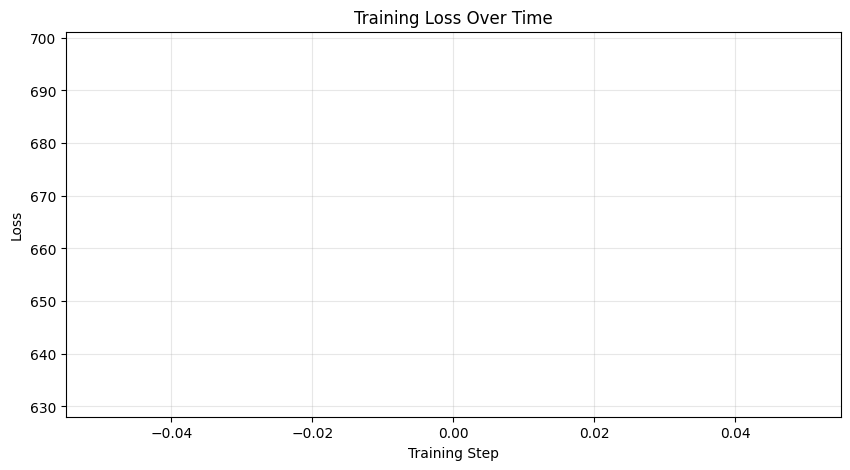


[5/6] Testing model...
Testing on 1229 time steps...


Testing:   0%|          | 1/1229 [00:00<16:30,  1.24it/s]

Structural Loss: nan (pos), nan (neg) | Neighbour Loss: nan (pos), nan (neg)


Testing:   0%|          | 2/1229 [00:01<13:48,  1.48it/s]

Structural Loss: nan (pos), nan (neg) | Neighbour Loss: nan (pos), nan (neg)


...

Testing:   4%|▎         | 44/1229 [00:25<12:06,  1.63it/s]

Structural Loss: nan (pos), nan (neg) | Neighbour Loss: nan (pos), nan (neg)


Testing:   4%|▎         | 45/1229 [00:26<11:41,  1.69it/s]

Structural Loss: nan (pos), nan (neg) | Neighbour Loss: nan (pos), nan (neg)


KeyboardInterrupt: 

In [ ]:
print("\n[1/6] Loading data...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load prices
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

all_stocks = prices.columns.tolist()
stock2idx = {s: i for i, s in enumerate(all_stocks)}
idx2stock = {i: s for s, i in stock2idx.items()}
N_full = len(all_stocks)

# Load sectors
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                        header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes


tickers = prices.columns.get_level_values(0).unique().tolist()
node_map = {ticker: i for i, ticker in enumerate(tickers)}

# Split data: Train 2007-2009, Test 2019-2021
train_prices = prices.loc['2012-01-01':'2019-12-31']
test_prices = prices.loc['2020-01-01':'2024-12-31']

returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')
returns = returns.ffill().bfill()
# Compute returns
# train_returns = train_prices.pct_change().dropna(how='all')
# test_returns = test_prices.pct_change().dropna(how='all')
train_returns = returns.loc['2012-01-01':'2019-12-31']
test_returns = returns.loc['2020-01-01':'2024-12-31']

# Compute volatility
train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)

# Helper to load and fix dates
def load_and_fix_index(filename):
    df = pd.read_csv(filename, index_col=0)
    df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
    df.dropna(how='all', inplace=True)
    df = df.ffill().bfill()
    return df

# Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')


print(f"Training period: {train_returns.index[0]} to {train_returns.index[-1]}")
print(f"Testing period: {test_returns.index[0]} to {test_returns.index[-1]}")
print(f"Number of stocks: {len(train_returns.columns)}")

# prep trainig and testing dates
print("\n[2/6] Preparing training dates...")

K = 21  # Window size
min_date = train_returns.index[0] + pd.Timedelta(days=K*2)
train_dates = train_returns.loc[min_date:].index

test_min_date = test_returns.index[0] + pd.Timedelta(days=K*2)
test_dates = test_returns.loc[test_min_date:].index

print(f"Training time steps: {len(train_dates)}")
print(f"Testing time steps: {len(test_dates)}")

# initialize model
print("\n[3/6] Initializing model...")

# Model hyperparameters
N = len(train_returns.columns)  # Number of stocks
feature_dim = 11  # [sector_id, volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, OpMargin, ROE, RSI, Turnover] TODO: try adding more features
embedding_dim = 10  # PCA embedding dimension (L)

gat_config = {
    'num_layers': 1,
    'heads': [1],  # Single attention head
    'features': [embedding_dim, 10]  # Input: L=10, Output: 10
}

model = GRASPEDmodel(
    gat_config=gat_config,
    hidden_dim=32,  # GRU hidden dimension
    output_dim=16,  # Spectral encoder output dimension
    feature_dim=feature_dim  # X_t has feature_dim=11 raw node features
)

optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-05)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# training
print("\n[4/6] Training model...")

# Create output directory
os.makedirs('outputs', exist_ok=True)

print(f'{device})')

training_losses = train_model(
    model, optimizer, train_returns, sectors, train_volatility, Market_caps, PE_ratios, Implied_vol,
    Short_interest, Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover,
    train_dates, stock2idx, K=K, save_path='outputs/bubble_model.pt'
)

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(training_losses)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(alpha=0.3)
plt.savefig('outputs/training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# testing
print("\n[5/6] Testing model...")
print(f'{device})')

test_results = test_model(model, test_returns, sectors, test_volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, 
            Operating_margin, Return_on_equity, RSI_momentum, Turnover, test_dates, stock2idx, K=21)

#print(f"Average bubble signal: {test_results.mean().mean():.4f}")
#print(f"Max bubble signal: {test_results.max().max():.4f}")

# Save results
pd.to_pickle(test_results, "outputs/test_results_test_GRASPED.pkl")
pd.to_pickle(test_prices, "outputs/test_prices_test_GRASPED.pkl")